# Pipeline de Preço Justo — Materiais Recicláveis

Pipeline de produção para calcular a tabela de **preço justo** (R$/kg) por tipo de material e estado.

**Modelo:** Lag-3m (mediana dos últimos 3 meses) — selecionado após validação temporal contra 7 modelos.

**Clusterização:** Name-Based Clustering (TF-IDF hierárquico com desambiguação por preço).

### Pipeline

1. Carga e limpeza dos dados
2. Classificação de operações (VENDA/COMPRA) e materiais (TF-IDF matching)
3. Refinamento do grupo OUTROS + Clusterização por nome (TF-IDF hierárquico)
4. Cálculo do preço justo via Lag-3m
5. Validação temporal (Walk-Forward CV) + Comparação mensal previsão vs real
6. Tabela de preço justo final + Exportação

In [77]:
import pandas as pd
import numpy as np
import re
import unicodedata
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.sparse import hstack

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_style("whitegrid")

PRICE_COL = "unitpricekg_product"
VENDA_CATS = ["VENDA", "VENDA INTERESTADUAL"]
TFIDF_THRESHOLD = 0.25
MATCH_SCORE_MIN = 0.6
MIN_OBS_FAIR_PRICE = 5
LAG_MONTHS = 1
PRICE_RATIO_THRESHOLD = 2.0
NAME_DIST_THRESHOLD = 0.50

PALETTE = ["#2C3E50", "#E74C3C", "#3498DB", "#27AE60", "#F39C12", "#9B59B6", "#1ABC9C", "#E67E22"]
GROUP_COLORS = {
    "PET": "#1f77b4", "PP": "#ff7f0e", "PEAD": "#2ca02c",
    "PS": "#d62728", "PE/FILME": "#9467bd", "PVC": "#8c564b",
    "BOPP/RAFIA": "#e377c2", "OUTROS": "#7f7f7f",
}

print("✓ Ambiente configurado")

✓ Ambiente configurado


## 1. Carga e Limpeza

In [78]:
df_invoices = pd.read_csv("products_invoices.csv")
df_estoque = pd.read_csv("consulta_estoque.csv")

# --- Limpeza: colunas desnecessárias ou >50% nulas ---
est_drop = ["_fivetran_synced", "_fivetran_deleted", "estoque_minimo", "reservado"]
est_null = df_estoque.columns[df_estoque.isnull().mean() > 0.5].tolist()
df_estoque = df_estoque.drop(columns=list(set(est_drop + est_null)), errors="ignore")

inv_drop = [
    "id_product", "fivetran_deleted_product",
    "id_operatorinvoice", "fivetran_deleted_operatorinvoice",
    "id_subsidiary", "fivetran_deleted_subsidiary", "companyid",
    "status_product", "product_invalidations", "product_nf",
    "licensecetesb", "sefaz_valida",
    "has_invoice_credit", "id_invoicecredit", "createdat_invoicecredit",
    "was_purchased", "purchaseordersids", "purchaseorders_codes",
    "was_compensation", "compensations_ids",
    "createdat_product", "createdat_operatorinvoice", "createdat_subsidiary",
    "danfe", "danfe_materials", "aditional_cpl_operatorinvoice",
    "isblocked_operatorinvoice", "volume_attention", "volume_attention_por_data",
    "invoice_in_offer",
    "emitterlegaldoc", "emitterlegalname", "emitterfantasyname",
    "emitterneighborhood", "emitternumber", "emitterphone",
    "emitterstreet", "emitterzipcode",
    "receiverlegaldoc", "receiverlegalname",
    "receivernumber", "receiverphone", "receiverstreet", "receiverzipcode",
    "status_subsidiary", "phone_subsidiary", "email_subsidiary",
    "address1_subsidiary", "neighbourhood_subsidiary",
    "number_subsidiary", "legalname_subsidiary", "cnpj_subsidiary",
    "zip_subsidiary",
]
inv_null = df_invoices.columns[df_invoices.isnull().mean() > 0.5].tolist()
df_invoices = df_invoices.drop(columns=list(set(inv_drop + inv_null)), errors="ignore")

df_invoices["emittedat_operatorinvoice"] = pd.to_datetime(
    df_invoices["emittedat_operatorinvoice"], errors="coerce"
)
df_invoices["year"] = df_invoices["emittedat_operatorinvoice"].dt.year
df_invoices["month"] = df_invoices["emittedat_operatorinvoice"].dt.month
df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")
df_invoices = df_invoices[df_invoices["year"].isin([2023, 2024, 2025])].copy()

print(f"✓ Notas carregadas: {len(df_invoices):,}")
print(f"  Estoque carregado: {len(df_estoque):,} produtos")

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_55844/493153720.py:1: DtypeWarning: Columns (87,89,91,92,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_invoices = pd.read_csv("products_invoices.csv")


✓ Notas carregadas: 87,943
  Estoque carregado: 66 produtos


/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_55844/493153720.py:40: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")


## 2. Classificação de Operações e Materiais

In [79]:
# ── Classificadores ──

def classify_natop(natop):
    if pd.isna(natop):
        return "OUTROS"
    s = str(natop).strip().lower()
    is_inter = any(kw in s for kw in [
        "interestadual", "inter estadual", "interstate",
        "fora do estado", "fora estado", "outros estados",
    ])
    if is_inter:
        if any(kw in s for kw in ["venda", "vda", "saida", "saída", "remessa", "sucata"]):
            return "VENDA INTERESTADUAL"
        if any(kw in s for kw in ["compra", "cpa", "entrada", "aquisicao", "aquisição"]):
            return "COMPRA INTERESTADUAL"
        return "OUTROS"
    if any(kw in s for kw in ["venda", "vda", "vnd"]):
        return "VENDA"
    if re.search(r"\bsaida\b|\bsaída\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "VENDA"
    if any(kw in s for kw in ["compra", "cpa"]):
        return "COMPRA"
    if re.search(r"\bentrada\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "COMPRA"
    if any(kw in s for kw in ["aquisicao", "aquisição"]):
        return "COMPRA"
    return "OUTROS"


def classify_material_group(text):
    if pd.isna(text):
        return "OUTROS"
    s = str(text).strip().upper()
    if "PEAD" in s:                              return "PEAD"
    if "PET" in s:                               return "PET"
    if "BOPP" in s or "RAFIA" in s:              return "BOPP/RAFIA"
    if "PP" in s:                                return "PP"
    if "PS" in s:                                return "PS"
    if "PVC" in s:                               return "PVC"
    if "PE " in s or "FILME" in s or s.startswith("PE"): return "PE/FILME"
    return "OUTROS"


def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return " ".join(s.split())


_CNAE_RE = re.compile(r'^\d{2}\.\d{2}-\d-\d{2}$')

def classify_cnae_sector(cnae):
    if pd.isna(cnae):
        return "DESCONHECIDO"
    s = str(cnae).strip()
    if not _CNAE_RE.match(s):
        return "DESCONHECIDO"
    div = s[:2]
    if div == "38":                          return "COLETA_RECICLAGEM"
    if div == "94" or div == "88":           return "COOPERATIVA"
    if s.startswith("46.87") or s.startswith("46.86"):
        return "COMERCIO_ATACADO"
    if div in ("22", "17", "23", "24", "25",
               "20", "28", "13", "15", "26",
               "27", "29", "30", "31", "32", "33"):
        return "INDUSTRIA"
    if div.startswith("4"):                  return "COMERCIO"
    return "OUTROS_SETOR"


# ── Sinônimos para normalização TF-IDF ──

SYNONYMS = {
    "LATAS DE ALUMINIO": "LATINHAS", "LATA DE ALUMINIO": "LATINHAS",
    "LATINHAS DE ALUMINIO": "LATINHAS", "LATINHA DE ALUMINIO": "LATINHAS",
    "LATA ALUMINIO": "LATINHAS", "LATAS ALUMINIO": "LATINHAS",
    "ALUMINIO LATA": "LATINHAS", "LATINHA": "LATINHAS",
    "SACOLAS": "SACOLINHA", "SACOLA": "SACOLINHA", "SACOLINHAS": "SACOLINHA",
    "FILME PEBD": "FILME", "FILME PE": "FILME", "PEBD": "PE",
    "RAFFIA": "RAFIA", "BIG BAGS": "RAFIA", "BIG BAG": "RAFIA", "BIGBAG": "RAFIA",
    "COPOS": "COPINHO", "COPO": "COPINHO",
    "POTES MARGARINA": "MARGARINA", "POTE MARGARINA": "MARGARINA",
    "POTE DE MARGARINA": "MARGARINA",
    "BALDES": "BALDE BACIA", "BALDE": "BALDE BACIA",
    "BACIAS": "BALDE BACIA", "BACIA": "BALDE BACIA",
    "TAMPAS": "TAMPINHA", "TAMPA": "TAMPINHA", "TAMPINHAS": "TAMPINHA",
    "PRE-FORMA": "PREFORMA", "PRE FORMA": "PREFORMA",
    "BANDEJAS": "BANDEJA",
    "APARAS DE": "SUCATA DE", "APARA DE": "SUCATA DE",
    "APARAS": "SUCATA", "APARA": "SUCATA",
    "POS CONSUMO": "", "POS-CONSUMO": "", "PRE CONSUMO": "", "PRE-CONSUMO": "",
    "RECICLADO": "", "RECICLADA": "", "TRITURADO": "", "TRITURADA": "",
    "MOIDO": "", "MOIDA": "",
}
_SORTED_SYNS = sorted(SYNONYMS.items(), key=lambda x: -len(x[0]))

def expand_synonyms(text):
    for old, new in _SORTED_SYNS:
        text = re.sub(r'\b' + re.escape(old) + r'\b', new, text)
    return " ".join(text.split())

print("✓ Classificadores definidos")

✓ Classificadores definidos


In [80]:
# ── Aplicar classificações ──

df_invoices["natop_category"] = df_invoices["natop_operatorinvoice"].apply(classify_natop)
df_estoque["material_group"] = df_estoque["c_descricao"].apply(classify_material_group)

mask = (
    df_invoices["material"].notna()
    & (df_invoices["material"].str.strip() != "")
    & (df_invoices["material"].str.strip().str.lower() != "unknown")
    & df_invoices["description_product"].notna()
    & (df_invoices["description_product"].str.strip() != "")
    & (df_invoices["natop_category"] != "OUTROS")
)
df_clean = df_invoices[mask].copy()

# ── TF-IDF Matching contra catálogo de estoque ──

estoque_products = sorted(set(
    p for p in df_estoque["c_descricao"].dropna().apply(normalize_text).unique() if p
))
estoque_expanded = [expand_synonyms(p) for p in estoque_products]
estoque_to_group = {}
for _, row in df_estoque.dropna(subset=["c_descricao"]).iterrows():
    key = normalize_text(row["c_descricao"])
    if key:
        estoque_to_group[key] = row["material_group"]

unique_descs = sorted(set(
    d for d in df_clean["description_product"].dropna().apply(normalize_text).unique() if d
))
descs_expanded = [expand_synonyms(d) for d in unique_descs]

all_expanded = estoque_expanded + descs_expanded
n_est = len(estoque_expanded)

vec_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
tfidf_char = vec_char.fit_transform(all_expanded)
sim_char = cosine_similarity(tfidf_char[n_est:], tfidf_char[:n_est])

vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
tfidf_word = vec_word.fit_transform(all_expanded)
sim_word = cosine_similarity(tfidf_word[n_est:], tfidf_word[:n_est])

sim_matrix = 0.5 * sim_char + 0.5 * sim_word

match_map = {}
for i, desc in enumerate(unique_descs):
    best_idx = sim_matrix[i].argmax()
    best_score = sim_matrix[i, best_idx]
    if best_score >= TFIDF_THRESHOLD:
        match_map[desc] = (estoque_products[best_idx], round(best_score, 3))
    else:
        match_map[desc] = ("SEM CORRESPONDENCIA", round(best_score, 3))

df_clean["desc_normalized"] = df_clean["description_product"].apply(normalize_text)
df_clean["estoque_product"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[0]
)
df_clean["match_score"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[1]
)
df_clean["material_group"] = df_clean["desc_normalized"].map(
    lambda d: estoque_to_group.get(match_map.get(d, ("", 0))[0], None)
)
mask_no_group = df_clean["material_group"].isna()
df_clean.loc[mask_no_group, "material_group"] = (
    df_clean.loc[mask_no_group, "material"].apply(classify_material_group)
)

df_matched = df_clean[df_clean["match_score"] > MATCH_SCORE_MIN].copy()

# ── Preço válido (outlier removal acontece após toda a clusterização) ──

df_price = df_matched.dropna(subset=[PRICE_COL]).copy()
df_price = df_price[df_price[PRICE_COL] > 0]

def remove_outliers_iqr(df, col, groupby_cols, k=1.5):
    clean_dfs = []
    for _, grp in df.groupby(groupby_cols):
        q1 = grp[col].quantile(0.25)
        q3 = grp[col].quantile(0.75)
        iqr = q3 - q1
        mask = (grp[col] >= q1 - k * iqr) & (grp[col] <= q3 + k * iqr)
        clean_dfs.append(grp[mask])
    return pd.concat(clean_dfs, ignore_index=True)

# Outlier removal será aplicado depois da clusterização completa (material_cluster)
df_price_clean = df_price.copy()

# ── Setor CNAE ──
df_price_clean["emitter_sector"] = df_price_clean["emittercnae"].apply(classify_cnae_sector)
df_price_clean["receiver_sector"] = df_price_clean["receivercnae"].apply(classify_cnae_sector)

print(f"✓ Pipeline de limpeza completo")
print(f"  Matched (score > {MATCH_SCORE_MIN}): {len(df_matched):,}")
print(f"  Com preço válido: {len(df_price_clean):,}")
print(f"  ⚠ Outlier removal adiado para após clusterização")

✓ Pipeline de limpeza completo
  Matched (score > 0.6): 21,269
  Com preço válido: 21,185
  ⚠ Outlier removal adiado para após clusterização


### Clusterização 1/3 — `material_group` (8 grupos originais)

Distribuição dos dados pelos 8 grupos de material original: PET, PP, PEAD, PS, PE/FILME, PVC, BOPP/RAFIA e OUTROS.

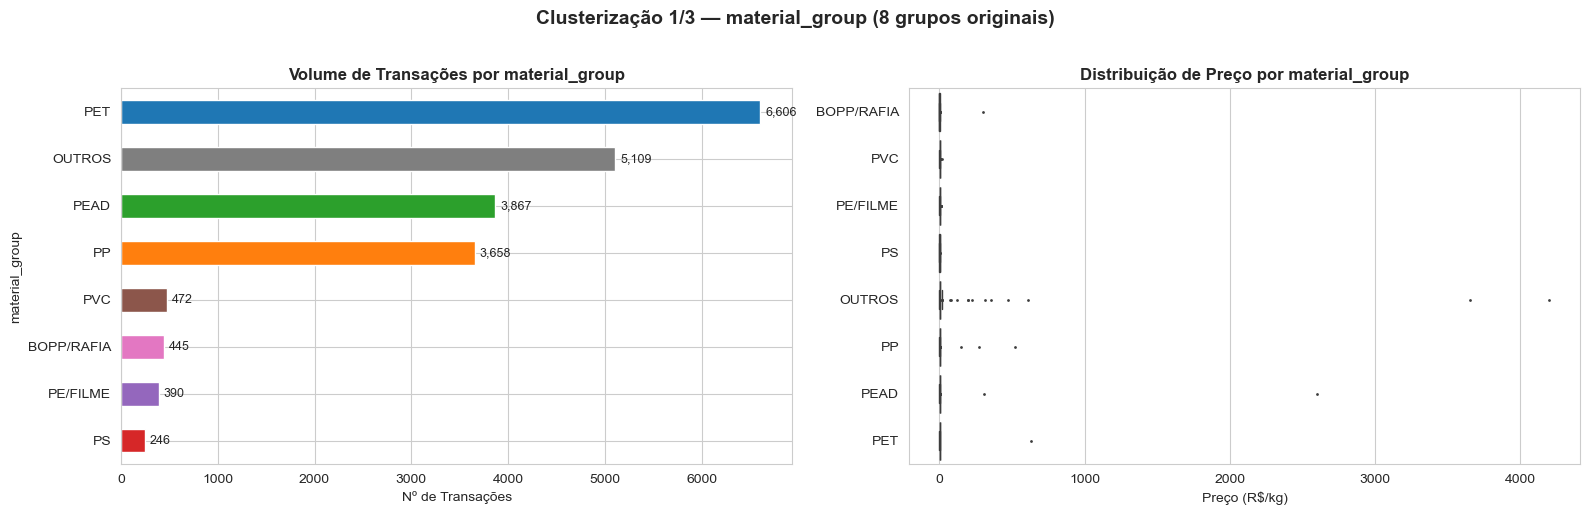


Grupos: 8
  PS                    n=   246  mediana=0.93  CV=0.729
  PE/FILME              n=   390  mediana=0.72  CV=1.238
  BOPP/RAFIA            n=   445  mediana=0.30  CV=13.328
  PVC                   n=   472  mediana=0.50  CV=1.273
  PP                    n= 3,658  mediana=1.60  CV=5.379
  PEAD                  n= 3,867  mediana=2.30  CV=14.785
  OUTROS                n= 5,109  mediana=1.60  CV=13.820
  PET                   n= 6,606  mediana=3.50  CV=2.333


In [81]:
# ── Visualização: material_group ──
df_vendas_pre = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()
groups = df_vendas_pre["material_group"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volume por grupo
ax = axes[0]
colors = [GROUP_COLORS.get(g, "#999") for g in groups.index]
groups.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.set_title("Volume de Transações por material_group", fontweight="bold")
ax.set_xlabel("Nº de Transações")
for i, v in enumerate(groups):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)

# Box-plot de preço por grupo
ax = axes[1]
order = df_vendas_pre.groupby("material_group")[PRICE_COL].median().sort_values().index
sns.boxplot(data=df_vendas_pre, y="material_group", x=PRICE_COL, order=order, ax=ax,
            palette=[GROUP_COLORS.get(g, "#999") for g in order], fliersize=1)
ax.set_title("Distribuição de Preço por material_group", fontweight="bold")
ax.set_xlabel("Preço (R$/kg)")
ax.set_ylabel("")

plt.suptitle("Clusterização 1/3 — material_group (8 grupos originais)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nGrupos: {len(groups)}")
for g in groups.index:
    sub = df_vendas_pre[df_vendas_pre['material_group'] == g]
    cv = sub[PRICE_COL].std() / sub[PRICE_COL].mean() if sub[PRICE_COL].mean() > 0 else 0
    print(f"  {g:20s}  n={len(sub):>6,}  mediana={sub[PRICE_COL].median():.2f}  CV={cv:.3f}")

## 3. Refinamento OUTROS + Clusterização por Nome

O grupo OUTROS misturava metais (8-12 R$/kg) com plásticos (0.5-2 R$/kg). O pipeline aplica **2 níveis de clusterização**:

1. **Refinamento OUTROS:** subdivisão baseada em keywords e preço
2. **Clusterização por nome (TF-IDF hierárquico):** agrupa produtos por similaridade textual, com desambiguação por preço quando a razão de preços dentro de um cluster excede `PRICE_RATIO_THRESHOLD`

In [82]:
def refine_outros(df):
    """Subdivide o grupo OUTROS em subtipos coerentes."""
    df = df.copy()
    def _classify(row):
        desc = str(row['estoque_product']).upper()
        price = row[PRICE_COL]
        if price > 4.0 or any(k in desc for k in ['LATIN', 'ALUMIN', 'LATA', 'COBRE']):
            return 'METAIS_DIVERSOS'
        mat = str(row.get('material', '')).upper()
        if mat == 'PET' or 'PET' in desc: return 'OUTROS_PET'
        if any(x in desc for x in ['PEAD', 'FILME', 'PEBD']): return 'OUTROS_PEAD'
        if 'PP' in desc or 'POLIPROPILENO' in desc: return 'OUTROS_PP'
        if 'PS' in desc: return 'OUTROS_PS'
        if 'PVC' in desc: return 'OUTROS_PVC'
        if any(x in desc for x in ['PLAST', 'SUCATA PLAST']): return 'OUTROS_PLASTICOS_MISTOS'
        if any(x in desc for x in ['PAPEL', 'CARTON', 'PAPELAO']): return 'OUTROS_PAPEIS'
        if any(x in desc for x in ['MADEIR', 'PALLET', 'MACICA']): return 'OUTROS_MADEIRA'
        return 'OUTROS_RESIDUAL'

    mask = df['material_group'] == 'OUTROS'
    df['material_group_refined'] = df['material_group']
    df.loc[mask, 'material_group_refined'] = df.loc[mask].apply(_classify, axis=1)
    return df


def cluster_by_name(df, group_col="material_group_refined"):
    """Cluster products by name similarity (TF-IDF hierarchical) with price disambiguation."""
    df = df.copy()
    df["material_cluster"] = df[group_col]

    for group_name, group_df in df.groupby(group_col):
        # Get unique products with median prices and counts
        prod_stats = (
            group_df.groupby("estoque_product")
            .agg(median_price=(PRICE_COL, "median"), count=(PRICE_COL, "count"))
            .reset_index()
        )
        if len(prod_stats) < 2:
            # Single product — cluster is GROUP::PRODUCT
            product = prod_stats["estoque_product"].iloc[0]
            df.loc[df[group_col] == group_name, "material_cluster"] = f"{group_name}::{product}"
            continue

        # Normalize names (NO expand_synonyms — preserves distinctions like PEBD ≠ FILME PEBD)
        names = prod_stats["estoque_product"].apply(normalize_text).values

        # Dual TF-IDF: char_wb(2,4) + word(1,2)
        vec_c = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
        vec_w = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
        tfidf_c = vec_c.fit_transform(names)
        tfidf_w = vec_w.fit_transform(names)
        X = hstack([tfidf_c, tfidf_w])

        # Hierarchical clustering on cosine distance
        dist = pdist(X.toarray(), metric="cosine")
        dist = np.nan_to_num(dist, nan=0.0)
        Z = linkage(dist, method="average")
        labels = fcluster(Z, t=NAME_DIST_THRESHOLD, criterion="distance")

        prod_stats["name_cluster"] = labels

        # Post-hoc price split: within each name cluster, split if price ratio > threshold
        final_labels = prod_stats["name_cluster"].copy()
        next_label = labels.max() + 1

        for cl in prod_stats["name_cluster"].unique():
            cl_mask = prod_stats["name_cluster"] == cl
            cl_prods = prod_stats[cl_mask]
            if len(cl_prods) < 2:
                continue
            max_p = cl_prods["median_price"].max()
            min_p = cl_prods["median_price"].min()
            if min_p > 0 and max_p / min_p > PRICE_RATIO_THRESHOLD:
                # Split using KMeans on log-prices
                log_prices = np.log1p(cl_prods["median_price"].values).reshape(-1, 1)
                km = KMeans(n_clusters=2, n_init=10, random_state=42)
                sub_labels = km.fit_predict(log_prices)
                for sl in range(1, 2):
                    idx_positions = cl_prods.index[sub_labels == sl]
                    final_labels.loc[idx_positions] = next_label
                    next_label += 1

        prod_stats["final_cluster"] = final_labels

        # Name clusters as GROUP::MOST_FREQUENT_PRODUCT
        cluster_names = {}
        for cl_id in prod_stats["final_cluster"].unique():
            cl_prods = prod_stats[prod_stats["final_cluster"] == cl_id]
            top_product = cl_prods.sort_values("count", ascending=False).iloc[0]["estoque_product"]
            cluster_names[cl_id] = f"{group_name}::{top_product}"

        # Map back to df
        product_to_cluster = dict(
            zip(prod_stats["estoque_product"], prod_stats["final_cluster"].map(cluster_names))
        )
        mask = df[group_col] == group_name
        df.loc[mask, "material_cluster"] = df.loc[mask, "estoque_product"].map(product_to_cluster)
        df.loc[mask & df["material_cluster"].isna(), "material_cluster"] = group_name

    return df


# ── Aplicar refinamento OUTROS ──
df_price_clean = refine_outros(df_price_clean)

print(f"✓ Grupo OUTROS refinado")
print(f"  Subgrupos: {sorted(df_price_clean['material_group_refined'].unique())}")

✓ Grupo OUTROS refinado
  Subgrupos: ['BOPP/RAFIA', 'METAIS_DIVERSOS', 'OUTROS_PLASTICOS_MISTOS', 'OUTROS_RESIDUAL', 'PE/FILME', 'PEAD', 'PET', 'PP', 'PS', 'PVC']


### Clusterização 2/3 — `material_group_refined` (OUTROS subdividido)

O grupo OUTROS é decomposto em subtipos: METAIS_DIVERSOS, OUTROS_PET, OUTROS_PEAD, OUTROS_PP, OUTROS_PLASTICOS_MISTOS, etc.

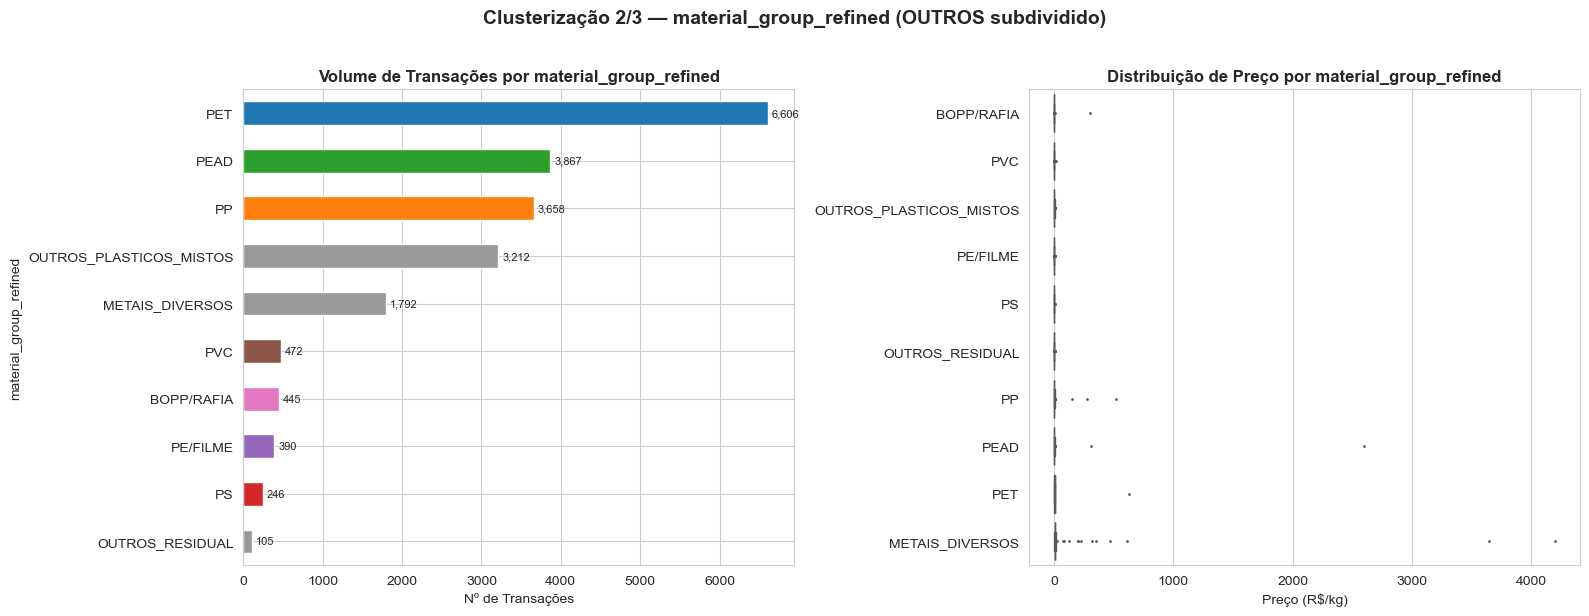


Grupo OUTROS original: n=5,109  CV=13.820
Após refinamento:
  METAIS_DIVERSOS                 n= 1,792  mediana=8.07  CV=9.198
  OUTROS_PLASTICOS_MISTOS         n= 3,212  mediana=0.60  CV=0.944
  OUTROS_RESIDUAL                 n=   105  mediana=1.00  CV=0.710


In [83]:
# ── Visualização: material_group_refined ──
df_vendas_ref = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()
groups_ref = df_vendas_ref["material_group_refined"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume por grupo refinado
ax = axes[0]
colors_ref = [GROUP_COLORS.get(g, "#999") for g in groups_ref.index]
groups_ref.plot(kind="barh", ax=ax, color=colors_ref, edgecolor="white")
ax.set_title("Volume de Transações por material_group_refined", fontweight="bold")
ax.set_xlabel("Nº de Transações")
for i, v in enumerate(groups_ref):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=8)

# Box-plot de preço por grupo refinado
ax = axes[1]
order = df_vendas_ref.groupby("material_group_refined")[PRICE_COL].median().sort_values().index
sns.boxplot(data=df_vendas_ref, y="material_group_refined", x=PRICE_COL, order=order, ax=ax,
            palette="Set2", fliersize=1)
ax.set_title("Distribuição de Preço por material_group_refined", fontweight="bold")
ax.set_xlabel("Preço (R$/kg)")
ax.set_ylabel("")

plt.suptitle("Clusterização 2/3 — material_group_refined (OUTROS subdividido)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Destaque: comparação OUTROS original vs subgrupos
outros_mask = df_vendas_ref["material_group"] == "OUTROS"
if outros_mask.any():
    outros_data = df_vendas_ref[outros_mask]
    cv_original = outros_data[PRICE_COL].std() / outros_data[PRICE_COL].mean()
    print(f"\nGrupo OUTROS original: n={len(outros_data):,}  CV={cv_original:.3f}")
    print(f"Após refinamento:")
    for g in sorted(outros_data["material_group_refined"].unique()):
        sub = outros_data[outros_data["material_group_refined"] == g]
        cv = sub[PRICE_COL].std() / sub[PRICE_COL].mean() if sub[PRICE_COL].mean() > 0 else 0
        print(f"  {g:30s}  n={len(sub):>6,}  mediana={sub[PRICE_COL].median():.2f}  CV={cv:.3f}")

In [84]:
# ── Aplicar clusterização por nome (TF-IDF hierárquico + desambiguação por preço) ──
df_price_clean = cluster_by_name(df_price_clean)

# Filtrar apenas VENDAS
df_vendas = df_price_clean[df_price_clean["natop_category"].isin(VENDA_CATS)].copy()

print(f"✓ Clusterização por nome concluída")
print(f"  Total de clusters: {df_vendas['material_cluster'].nunique()}")
print(f"  Registros de venda: {len(df_vendas):,}")
print(f"\nExemplos de clusters:")
for cl in sorted(df_vendas['material_cluster'].unique())[:15]:
    n = (df_vendas['material_cluster'] == cl).sum()
    print(f"    {cl}: {n:,} registros")

✓ Clusterização por nome concluída
  Total de clusters: 44
  Registros de venda: 20,793

Exemplos de clusters:
    BOPP/RAFIA::PP RAFIA: 136 registros
    BOPP/RAFIA::SUCATA DE RAFIA: 309 registros
    METAIS_DIVERSOS::SUCATA DE AEROSOL: 2 registros
    METAIS_DIVERSOS::SUCATA DE LATINHAS: 1,521 registros
    METAIS_DIVERSOS::SUCATA DE PLASTICO: 269 registros
    OUTROS_PLASTICOS_MISTOS::PLASTICOS DIVERSOS: 70 registros
    OUTROS_PLASTICOS_MISTOS::SUCATA DE PLASTICO: 3,142 registros
    OUTROS_RESIDUAL::SUCATA DE AEROSOL: 6 registros
    OUTROS_RESIDUAL::SUCATA DE BALDE BACIA PRETO: 99 registros
    PE/FILME::PE CANELA: 46 registros
    PE/FILME::PE PRETO / PE COLORIDO: 82 registros
    PE/FILME::SUCATA DE FILME CANELA: 12 registros
    PE/FILME::SUCATA DE FILME COLORIDO: 250 registros
    PEAD::PEAD BOMBONA: 48 registros
    PEAD::PEAD COLORIDO (GARRAFA): 4 registros


### Clusterização 3/3 — `material_cluster` (clusters por nome com desambiguação por preço)

Cada `material_group_refined` é subdividido por similaridade textual (TF-IDF hierárquico, `NAME_DIST_THRESHOLD=0.50`) e, quando a razão de preços dentro de um cluster excede `PRICE_RATIO_THRESHOLD=2.0`, o cluster é separado por preço via KMeans. Esta é a clusterização final usada pelo modelo.

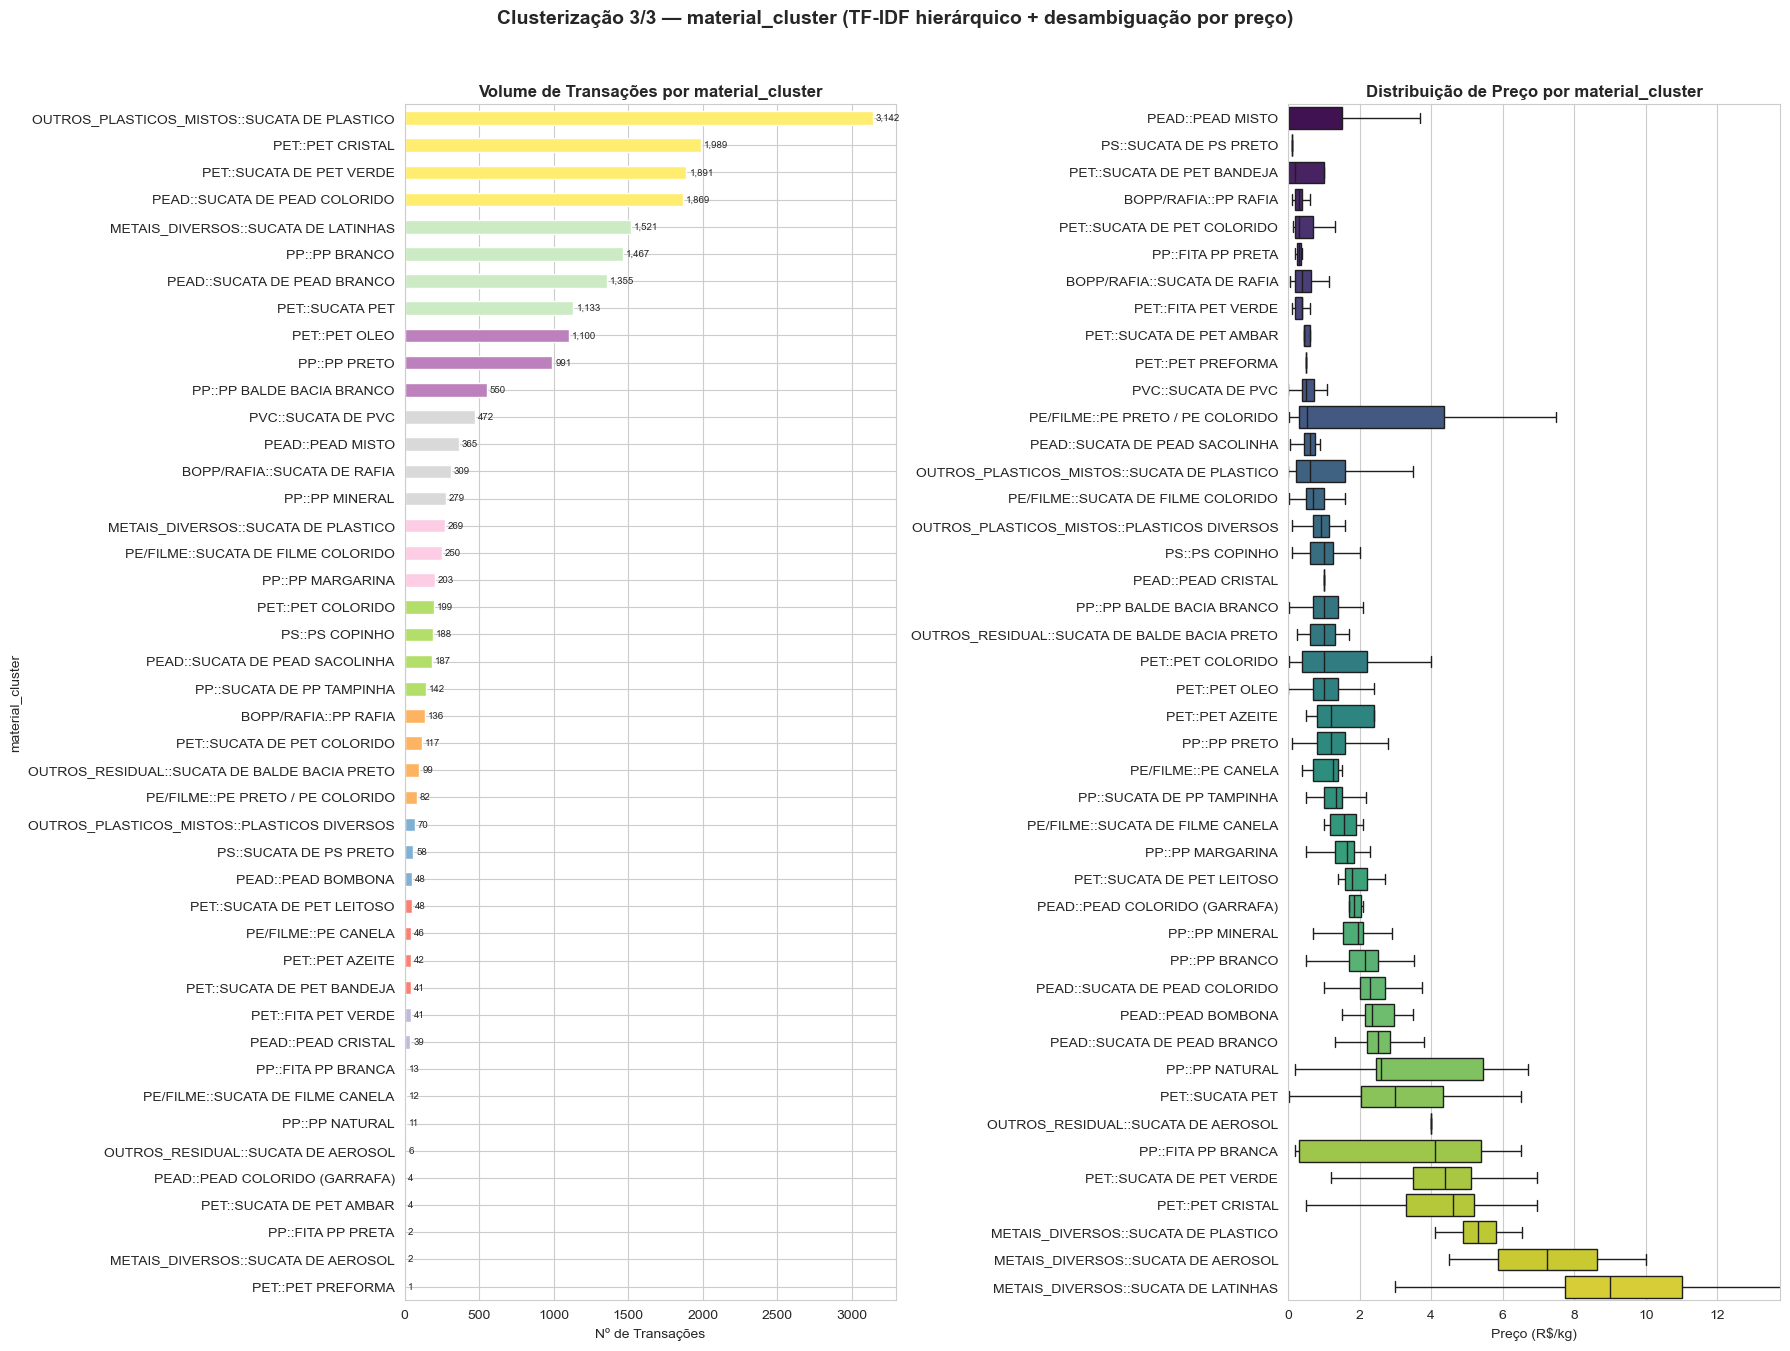


Total de clusters: 44

Cluster                                                  n  Mediana     CV
───────────────────────────────────────────────────────────────────────────
  PEAD::PEAD MISTO                                     365    0.02  1.359
  PS::SUCATA DE PS PRETO                                58    0.10  2.931
  PET::SUCATA DE PET BANDEJA                            41    0.20  1.020
  BOPP/RAFIA::PP RAFIA                                 136    0.30 10.079
  PET::SUCATA DE PET COLORIDO                          117    0.30  1.351
  PP::FITA PP PRETA                                      2    0.30  0.471
  BOPP/RAFIA::SUCATA DE RAFIA                          309    0.40  0.524
  PET::FITA PET VERDE                                   41    0.40  1.163
  PET::SUCATA DE PET AMBAR                               4    0.45  0.554
  PET::PET PREFORMA                                      1    0.50    nan
  PVC::SUCATA DE PVC                                   472    0.50  1.273
  PE/FILME:

In [85]:
# ── Visualização: material_cluster (clusterização final) ──
tiers = df_vendas["material_cluster"].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(tiers) * 0.3)))

# Volume por material_cluster
ax = axes[0]
tier_colors = plt.cm.Set3(np.linspace(0, 1, len(tiers)))
tiers.plot(kind="barh", ax=ax, color=tier_colors, edgecolor="white")
ax.set_title("Volume de Transações por material_cluster", fontweight="bold")
ax.set_xlabel("Nº de Transações")
for i, v in enumerate(tiers):
    ax.text(v + 20, i, f"{v:,}", va="center", fontsize=7)

# Box-plot de preço por material_cluster
ax = axes[1]
order = df_vendas.groupby("material_cluster")[PRICE_COL].median().sort_values().index
sns.boxplot(data=df_vendas, y="material_cluster", x=PRICE_COL, order=order, ax=ax,
            palette="viridis", fliersize=0, showfliers=False)
ax.set_title("Distribuição de Preço por material_cluster", fontweight="bold")
ax.set_xlabel("Preço (R$/kg)")
ax.set_ylabel("")
x_max = df_vendas[PRICE_COL].quantile(0.99) * 1.1
ax.set_xlim(0, x_max)

plt.suptitle("Clusterização 3/3 — material_cluster (TF-IDF hierárquico + desambiguação por preço)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Resumo com CV por cluster
print(f"\nTotal de clusters: {len(tiers)}")
print(f"\n{'Cluster':<50s} {'n':>7s} {'Mediana':>8s} {'CV':>6s}")
print("─" * 75)
for g in df_vendas.groupby("material_cluster")[PRICE_COL].median().sort_values().index:
    sub = df_vendas[df_vendas["material_cluster"] == g]
    cv = sub[PRICE_COL].std() / sub[PRICE_COL].mean() if sub[PRICE_COL].mean() > 0 else 0
    print(f"  {g:<48s} {len(sub):>7,} {sub[PRICE_COL].median():>7.2f} {cv:>6.3f}")

### Diagnóstico — Produtos dentro dos clusters com alta variabilidade

Os clusters abaixo ainda apresentam CV elevado. Inspecionamos quais produtos estão misturados dentro de cada um para entender a fonte da variância.

In [86]:
# ── Diagnóstico: produtos por cluster com alta variabilidade ──

available_clusters = df_vendas["material_cluster"].unique()

# Pick clusters with CV > 0.3
cluster_cvs = {}
for t in available_clusters:
    sub = df_vendas[df_vendas["material_cluster"] == t]
    if len(sub) >= 10 and sub[PRICE_COL].mean() > 0:
        cluster_cvs[t] = sub[PRICE_COL].std() / sub[PRICE_COL].mean()
inspect_clusters = [t for t, cv in sorted(cluster_cvs.items(), key=lambda x: -x[1]) if cv > 0.3][:8]

print(f"Clusters a inspecionar (CV > 0.3): {len(inspect_clusters)}\n")
print("=" * 100)

for cluster in inspect_clusters:
    sub = df_vendas[df_vendas["material_cluster"] == cluster]
    cv = sub[PRICE_COL].std() / sub[PRICE_COL].mean() if sub[PRICE_COL].mean() > 0 else 0
    print(f"\n{'━' * 100}")
    print(f"CLUSTER: {cluster}  |  n={len(sub):,}  |  mediana={sub[PRICE_COL].median():.2f}  |  CV={cv:.3f}")
    print(f"{'━' * 100}")

    # Product breakdown
    prod_stats = (
        sub.groupby("estoque_product")[PRICE_COL]
        .agg(["count", "median", "mean", "std", "min", "max"])
        .sort_values("median", ascending=False)
    )
    prod_stats["std"] = prod_stats["std"].fillna(0)
    prod_stats["cv"] = np.where(prod_stats["mean"] > 0, prod_stats["std"] / prod_stats["mean"], 0)
    prod_stats["count"] = prod_stats["count"].astype(int)

    print(f"\n{'Produto':<45s} {'n':>6s} {'Min':>7s} {'Med':>7s} {'Max':>7s} {'CV':>6s}")
    print("─" * 80)
    for prod, row in prod_stats.iterrows():
        flag = " ⚠️" if row["cv"] > 0.3 else ""
        print(f"  {str(prod)[:43]:<43s} {int(row['count']):>6,} {row['min']:>7.2f} {row['median']:>7.2f} {row['max']:>7.2f} {row['cv']:>6.3f}{flag}")

    # Price range within cluster
    price_range = sub[PRICE_COL].max() - sub[PRICE_COL].min()
    print(f"\n  Range de preço no cluster: {sub[PRICE_COL].min():.2f} – {sub[PRICE_COL].max():.2f} (Δ = {price_range:.2f} R$/kg)")
    print(f"  Produtos distintos: {sub['estoque_product'].nunique()}")

Clusters a inspecionar (CV > 0.3): 8


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLUSTER: PEAD::SUCATA DE PEAD COLORIDO  |  n=1,869  |  mediana=2.30  |  CV=16.604
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Produto                                            n     Min     Med     Max     CV
────────────────────────────────────────────────────────────────────────────────
  SUCATA DE PEAD COLORIDO                      1,869    0.04    2.30 2600.00 16.604 ⚠️

  Range de preço no cluster: 0.04 – 2600.00 (Δ = 2599.96 R$/kg)
  Produtos distintos: 1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLUSTER: BOPP/RAFIA::PP RAFIA  |  n=136  |  mediana=0.30  |  CV=10.079
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Produto                                            n     Min

### Remoção de Outliers (após clusterização completa)

A remoção de outliers é feita **depois** de toda a clusterização (`material_cluster`) para:
- Não comprometer a formação dos clusters
- Remover ruído **dentro** de cada categoria final

In [87]:
# ── Remoção de outliers por material_cluster ──
n_before = len(df_vendas)
df_vendas = remove_outliers_iqr(df_vendas, PRICE_COL, ["material_cluster", "emitterstateuf"])
n_after = len(df_vendas)

print(f"✓ Outlier removal aplicado por [material_cluster, emitterstateuf]")
print(f"  Antes: {n_before:,} registros")
print(f"  Após:  {n_after:,} registros")
print(f"  Removidos: {n_before - n_after:,} ({(n_before - n_after) / n_before * 100:.1f}%)")

✓ Outlier removal aplicado por [material_cluster, emitterstateuf]
  Antes: 20,793 registros
  Após:  19,659 registros
  Removidos: 1,134 (5.5%)


## 4. Cálculo do Preço Justo — Lag-3m

Para cada combinação **material_cluster × estado**, calculamos:
- **Lag-3m:** mediana do preço dos últimos 3 meses (previsão para o próximo mês)
- **Fair price (histórico):** Q1 (compra), mediana (referência), Q3 (venda)
- **Quality tier:** confiança baseada em volume e homogeneidade

In [88]:
CLUSTER_COL = "material_cluster"

# ── Agregação mensal ──
monthly = (
    df_vendas.groupby([CLUSTER_COL, "emitterstateuf", "year", "month"])
    .agg(
        price_median=(PRICE_COL, "median"),
        price_mean=(PRICE_COL, "mean"),
        price_q25=(PRICE_COL, lambda x: x.quantile(0.25)),
        price_q75=(PRICE_COL, lambda x: x.quantile(0.75)),
        price_std=(PRICE_COL, "std"),
        n_transactions=(PRICE_COL, "count"),
    ).reset_index()
)
monthly["price_std"] = monthly["price_std"].fillna(0)
monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-01"
)

# ── Calcular Lag-3m por série ──
lag_dfs = []
for (grp, state), sub in monthly.groupby([CLUSTER_COL, "emitterstateuf"]):
    sub = sub.sort_values("date").copy()
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(LAG_MONTHS, min_periods=1).median()
    lag_dfs.append(sub)

monthly = pd.concat(lag_dfs, ignore_index=True)

# ── Preço justo via Lag-3m: pegar o último valor disponível ──
latest = monthly.dropna(subset=["lag_3m"]).sort_values("date").groupby(
    [CLUSTER_COL, "emitterstateuf"]
).last().reset_index()

print(f"✓ Lag-3m calculado")
print(f"  Séries mensais: {len(monthly):,}")
print(f"  Pares cluster × estado com previsão: {len(latest):,}")
print(f"  Último mês disponível: {monthly['date'].max().strftime('%Y-%m')}")

✓ Lag-3m calculado
  Séries mensais: 4,024
  Pares cluster × estado com previsão: 267
  Último mês disponível: 2025-12


## 4b. Validação Temporal — Walk-Forward Cross-Validation

**Walk-Forward CV com janela expansível:** para cada mês de 2025, usamos apenas dados anteriores para computar o Lag-3m e comparamos com o preço real do mês.

Isso simula exatamente como o modelo seria usado na prática — sem data leakage.

**Métricas:** MAE (R$/kg), RMSE, R², MAPE (%), % previsões dentro de ±20%.

In [89]:
# ══════════════════════════════════════════════════════════════
#  WALK-FORWARD CROSS-VALIDATION — LAG-3m
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Months to evaluate (2025)
months_2025 = sorted(monthly[monthly["year"] == 2025]["date"].unique())
print(f"Walk-Forward CV: {len(months_2025)} folds (2025)")
print(f"Cluster col: {CLUSTER_COL}\n")

cv_results = []
all_test_rows = []

for target_date in months_2025:
    target_month = pd.Timestamp(target_date)
    month_label = target_month.strftime("%Y-%m")

    # Train: all months before the target month
    train = monthly[monthly["date"] < target_month].copy()
    # Test: the target month
    test = monthly[monthly["date"] == target_month].copy()

    if len(test) == 0:
        continue

    # Compute Lag-3m using ONLY training data (no leakage)
    for (grp, state), sub in train.groupby([CLUSTER_COL, "emitterstateuf"]):
        sub = sub.sort_values("date")
        last_3 = sub["price_median"].tail(LAG_MONTHS)
        if len(last_3) > 0:
            pred = last_3.median()
            mask = (test[CLUSTER_COL] == grp) & (test["emitterstateuf"] == state)
            test.loc[mask, "pred_lag3m"] = pred

    # Also compute median baseline using training data
    for (grp, state), sub in train.groupby([CLUSTER_COL, "emitterstateuf"]):
        median_pred = sub["price_median"].median()
        mask = (test[CLUSTER_COL] == grp) & (test["emitterstateuf"] == state)
        test.loc[mask, "pred_median"] = median_pred

    # Evaluate
    test_valid = test.dropna(subset=["pred_lag3m", "price_median"]).copy()
    if len(test_valid) == 0:
        continue

    y_true = test_valid["price_median"]
    y_pred = test_valid["pred_lag3m"]
    y_pred_med = test_valid["pred_median"]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
    mape = (np.abs((y_true - y_pred) / y_true.clip(lower=0.01)) * 100).median()
    pct_within_20 = ((np.abs((y_true - y_pred) / y_true.clip(lower=0.01)) * 100) < 20).mean() * 100

    mae_med = mean_absolute_error(y_true, y_pred_med)

    cv_results.append({
        "month": month_label,
        "n_series": len(test_valid),
        "MAE_Lag3m": round(mae, 4),
        "MAE_Median": round(mae_med, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "MAPE_%": round(mape, 1),
        "within_20%": round(pct_within_20, 1),
    })

    test_valid["month_label"] = month_label
    all_test_rows.append(test_valid)

df_cv = pd.DataFrame(cv_results)
df_cv_detail = pd.concat(all_test_rows, ignore_index=True) if all_test_rows else pd.DataFrame()

# ── Summary table ──
print(f"{'Mês':<10s} {'n':>5s} {'MAE Lag3m':>10s} {'MAE Median':>11s} {'RMSE':>8s} {'R²':>7s} {'MAPE%':>7s} {'±20%':>7s}")
print("─" * 72)
for _, r in df_cv.iterrows():
    print(f"  {r['month']:<8s} {r['n_series']:>5} {r['MAE_Lag3m']:>10.4f} {r['MAE_Median']:>11.4f} "
          f"{r['RMSE']:>8.4f} {r['R2']:>7.4f} {r['MAPE_%']:>6.1f}% {r['within_20%']:>6.1f}%")

print(f"\n{'─' * 72}")
print(f"  {'MÉDIA':<8s} {int(df_cv['n_series'].mean()):>5} {df_cv['MAE_Lag3m'].mean():>10.4f} "
      f"{df_cv['MAE_Median'].mean():>11.4f} {df_cv['RMSE'].mean():>8.4f} {df_cv['R2'].mean():>7.4f} "
      f"{df_cv['MAPE_%'].mean():>6.1f}% {df_cv['within_20%'].mean():>6.1f}%")
print(f"  {'DESVIO':<8s} {'':>5s} {df_cv['MAE_Lag3m'].std():>10.4f} {df_cv['MAE_Median'].std():>11.4f}")

print(f"\n✓ Walk-Forward CV completo")
print(f"  Lag-3m MAE médio: {df_cv['MAE_Lag3m'].mean():.4f} ± {df_cv['MAE_Lag3m'].std():.4f} R$/kg")
print(f"  Baseline (Mediana) MAE médio: {df_cv['MAE_Median'].mean():.4f} R$/kg")
improvement = (1 - df_cv['MAE_Lag3m'].mean() / df_cv['MAE_Median'].mean()) * 100
print(f"  Melhoria Lag3m vs Mediana: {improvement:+.1f}%")
print(f"  R² médio: {df_cv['R2'].mean():.4f}")
print(f"  Previsões dentro de ±20%: {df_cv['within_20%'].mean():.1f}%")

Walk-Forward CV: 12 folds (2025)
Cluster col: material_cluster

Mês            n  MAE Lag3m  MAE Median     RMSE      R²   MAPE%    ±20%
────────────────────────────────────────────────────────────────────────
  2025-01    120     0.4195      0.6926   0.8656  0.9025    7.0%   65.8%
  2025-02    128     0.3118      0.6857   0.7402  0.9281    3.2%   78.9%
  2025-03    126     0.2854      0.6846   0.6263  0.9565    3.7%   74.6%
  2025-04    134     0.3234      0.6058   0.5692  0.9536    8.9%   74.6%
  2025-05    116     0.3966      0.5409   0.8175  0.8859    8.6%   73.3%
  2025-06    130     0.2693      0.4715   0.5201  0.9530    4.3%   77.7%
  2025-07    127     0.2882      0.5482   0.6453  0.9313    4.4%   76.4%
  2025-08    137     0.2913      0.5475   0.6340  0.9342    4.5%   76.6%
  2025-09    147     0.2809      0.5852   0.6047  0.9363    2.6%   82.3%
  2025-10    156     2.1521      2.4496  23.7881  0.0073    2.5%   77.6%
  2025-11    143     0.1988      0.4529   0.4956  0.9545    

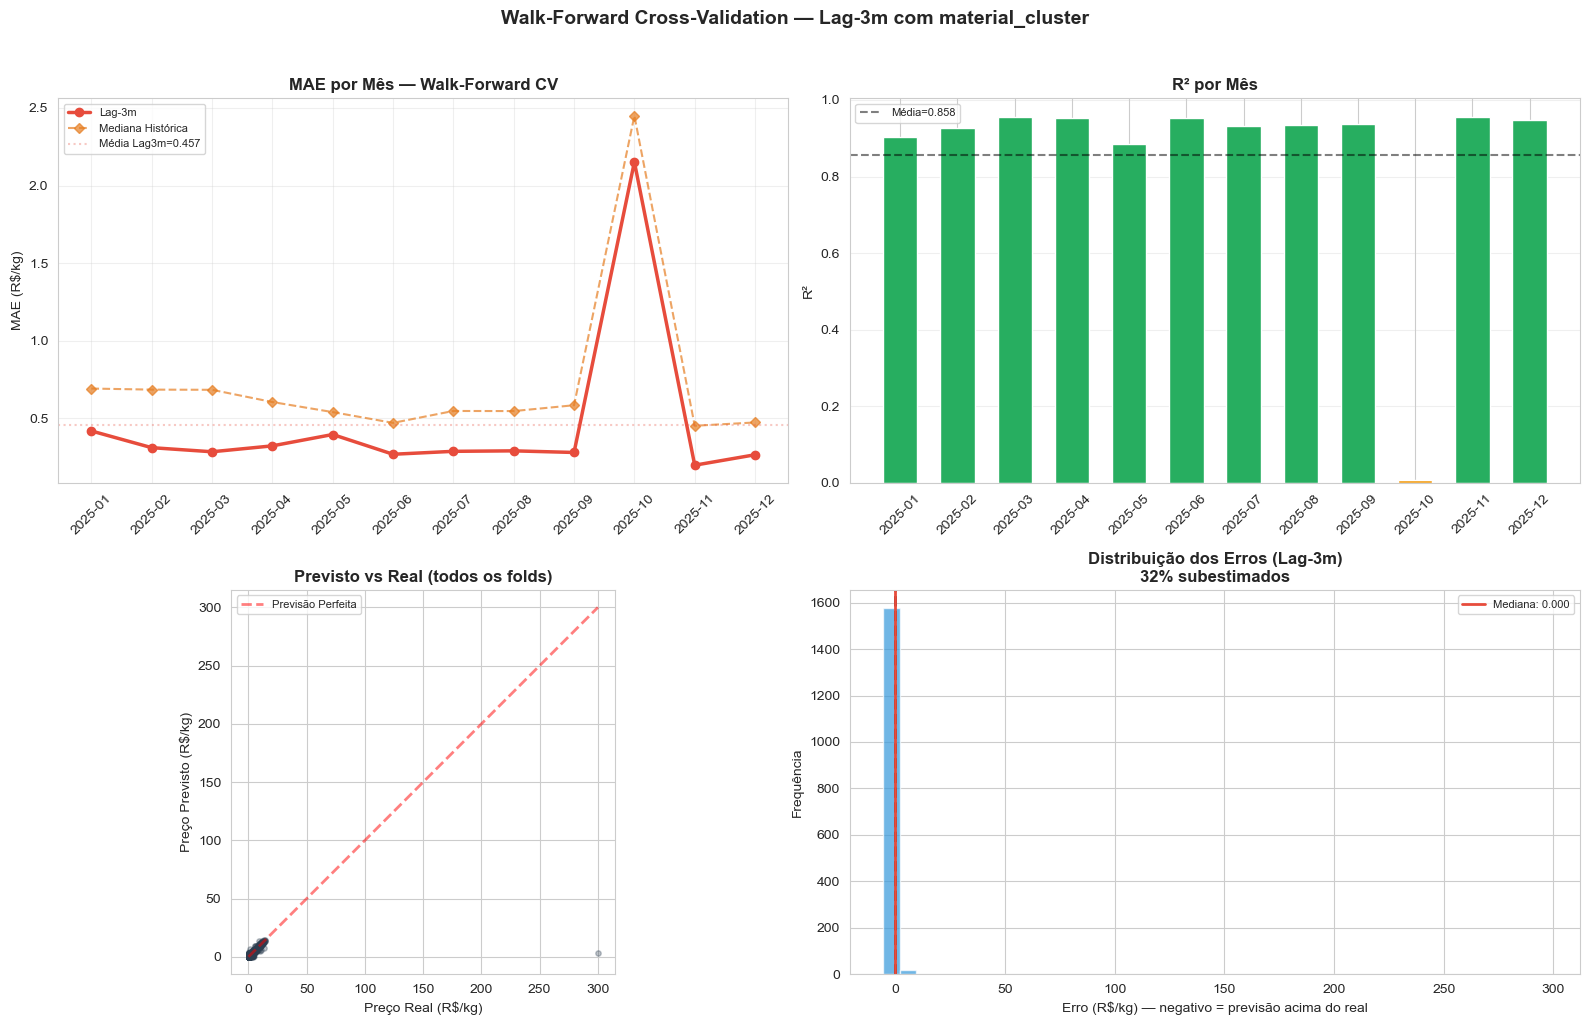


Estatísticas do erro (1594 previsões):
  Erro mediano: 0.0000 R$/kg
  MAE: 0.4813 R$/kg
  90% dos erros < 0.8000 R$/kg
  95% dos erros < 1.3175 R$/kg
  Previsões dentro de ±10%: 63.2%
  Previsões dentro de ±20%: 76.7%
  Previsões dentro de ±30%: 82.0%


In [90]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZAÇÃO — WALK-FORWARD CV
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) MAE por mês — Lag3m vs Mediana
ax = axes[0, 0]
ax.plot(df_cv["month"], df_cv["MAE_Lag3m"], "o-", color=PALETTE[1], linewidth=2.5, markersize=6, label="Lag-3m", zorder=5)
ax.plot(df_cv["month"], df_cv["MAE_Median"], "D--", color=PALETTE[7] if len(PALETTE) > 7 else "#95A5A6",
        linewidth=1.5, markersize=5, label="Mediana Histórica", alpha=0.7)
ax.axhline(df_cv["MAE_Lag3m"].mean(), color=PALETTE[1], linestyle=":", alpha=0.3, label=f"Média Lag3m={df_cv['MAE_Lag3m'].mean():.3f}")
ax.set_title("MAE por Mês — Walk-Forward CV", fontweight="bold")
ax.set_ylabel("MAE (R$/kg)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2) R² por mês
ax = axes[0, 1]
colors_r2 = [PALETTE[3] if v >= 0.5 else PALETTE[4] if v >= 0 else "#E74C3C" for v in df_cv["R2"]]
ax.bar(df_cv["month"], df_cv["R2"], color=colors_r2, edgecolor="white", width=0.6)
ax.axhline(df_cv["R2"].mean(), color="black", linestyle="--", alpha=0.5, label=f"Média={df_cv['R2'].mean():.3f}")
ax.set_title("R² por Mês", fontweight="bold")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# 3) Scatter: previsto vs real (all folds combined from df_cv_detail)
ax = axes[1, 0]
ax.scatter(df_cv_detail["price_median"], df_cv_detail["pred_lag3m"], alpha=0.3, s=15, color=PALETTE[0])
max_val = max(df_cv_detail["price_median"].max(), df_cv_detail["pred_lag3m"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, alpha=0.5, label="Previsão Perfeita")
ax.set_title("Previsto vs Real (todos os folds)", fontweight="bold")
ax.set_xlabel("Preço Real (R$/kg)")
ax.set_ylabel("Preço Previsto (R$/kg)")
ax.legend(fontsize=8)
ax.set_aspect("equal")

# 4) Distribuição dos erros
ax = axes[1, 1]
errors = df_cv_detail["price_median"] - df_cv_detail["pred_lag3m"]
ax.hist(errors, bins=40, color=PALETTE[2], alpha=0.7, edgecolor="white")
ax.axvline(0, color="black", linewidth=2, linestyle="--")
ax.axvline(errors.median(), color=PALETTE[1], linewidth=2, label=f"Mediana: {errors.median():.3f}")
pct_neg = (errors < 0).mean() * 100
ax.set_title(f"Distribuição dos Erros (Lag-3m)\n{pct_neg:.0f}% subestimados", fontweight="bold")
ax.set_xlabel("Erro (R$/kg) — negativo = previsão acima do real")
ax.set_ylabel("Frequência")
ax.legend(fontsize=8)

plt.suptitle("Walk-Forward Cross-Validation — Lag-3m com material_cluster",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
abs_errors = errors.abs()
pct_error = (errors / df_cv_detail["price_median"].clip(lower=0.01) * 100)
print(f"\nEstatísticas do erro ({len(df_cv_detail)} previsões):")
print(f"  Erro mediano: {errors.median():.4f} R$/kg")
print(f"  MAE: {abs_errors.mean():.4f} R$/kg")
print(f"  90% dos erros < {abs_errors.quantile(0.9):.4f} R$/kg")
print(f"  95% dos erros < {abs_errors.quantile(0.95):.4f} R$/kg")
print(f"  Previsões dentro de ±10%: {(pct_error.abs() < 10).mean() * 100:.1f}%")
print(f"  Previsões dentro de ±20%: {(pct_error.abs() < 20).mean() * 100:.1f}%")
print(f"  Previsões dentro de ±30%: {(pct_error.abs() < 30).mean() * 100:.1f}%")

### Comparação Mensal — Previsão vs Real

Para cada mês de 2025, comparamos o preço **previsto (Lag-3m)** com o preço **real observado** por cluster × estado. Isso permite avaliar a precisão do modelo série a série e identificar onde ele acerta e erra.

In [91]:
# ══════════════════════════════════════════════════════════════
#  COMPARAÇÃO MENSAL — PREVISÃO vs REAL
# ══════════════════════════════════════════════════════════════

# ── 1. Tabela mensal: previsto vs real por cluster ──
df_cv_detail["error"] = df_cv_detail["price_median"] - df_cv_detail["pred_lag3m"]
df_cv_detail["abs_error"] = df_cv_detail["error"].abs()
df_cv_detail["pct_error"] = (df_cv_detail["error"] / df_cv_detail["price_median"].clip(lower=0.01)) * 100

# Monthly precision summary
monthly_precision = (
    df_cv_detail.groupby("month_label")
    .agg(
        n_series=("price_median", "count"),
        real_mean=("price_median", "mean"),
        pred_mean=("pred_lag3m", "mean"),
        mae=("abs_error", "mean"),
        mape=("pct_error", lambda x: x.abs().median()),
        within_10=("pct_error", lambda x: (x.abs() < 10).mean() * 100),
        within_20=("pct_error", lambda x: (x.abs() < 20).mean() * 100),
        within_30=("pct_error", lambda x: (x.abs() < 30).mean() * 100),
    )
    .reset_index()
)

print("PRECISÃO MENSAL — Previsão Lag-3m vs Preço Real")
print("=" * 95)
print(f"{'Mês':<10s} {'n':>4s} {'Real Médio':>11s} {'Prev Médio':>11s} {'MAE':>8s} {'MAPE%':>7s} {'±10%':>6s} {'±20%':>6s} {'±30%':>6s}")
print("─" * 95)
for _, r in monthly_precision.iterrows():
    print(f"  {r['month_label']:<8s} {int(r['n_series']):>4} {r['real_mean']:>10.3f} {r['pred_mean']:>10.3f} "
          f"{r['mae']:>8.4f} {r['mape']:>6.1f}% {r['within_10']:>5.1f}% {r['within_20']:>5.1f}% {r['within_30']:>5.1f}%")
print("─" * 95)
print(f"  {'MÉDIA':<8s} {int(monthly_precision['n_series'].mean()):>4} "
      f"{monthly_precision['real_mean'].mean():>10.3f} {monthly_precision['pred_mean'].mean():>10.3f} "
      f"{monthly_precision['mae'].mean():>8.4f} {monthly_precision['mape'].mean():>6.1f}% "
      f"{monthly_precision['within_10'].mean():>5.1f}% {monthly_precision['within_20'].mean():>5.1f}% "
      f"{monthly_precision['within_30'].mean():>5.1f}%")

# ── 2. Top clusters: previsto vs real por mês ──
top_clusters = df_cv_detail.groupby(CLUSTER_COL)["price_median"].count().nlargest(8).index.tolist()

print(f"\n\nDETALHE — Top 8 clusters (por volume de séries)")
print("=" * 110)
for cluster_name in top_clusters:
    cl_data = df_cv_detail[df_cv_detail[CLUSTER_COL] == cluster_name].sort_values("month_label")
    cl_mae = cl_data["abs_error"].mean()
    cl_mape = cl_data["pct_error"].abs().median()
    print(f"\n{'━' * 110}")
    print(f"  {cluster_name}  |  MAE={cl_mae:.4f} R$/kg  |  MAPE={cl_mape:.1f}%  |  n={len(cl_data)} meses×estados")
    print(f"  {'Mês':<10s} {'Estado':<6s} {'Real':>8s} {'Previsto':>9s} {'Erro':>8s} {'Erro%':>7s}")
    print(f"  {'─' * 55}")
    for _, row in cl_data.iterrows():
        err_pct = row["pct_error"]
        flag = " ⚠️" if abs(err_pct) > 20 else ""
        print(f"  {row['month_label']:<10s} {row['emitterstateuf']:<6s} {row['price_median']:>8.3f} "
              f"{row['pred_lag3m']:>9.3f} {row['error']:>+8.3f} {err_pct:>+6.1f}%{flag}")

PRECISÃO MENSAL — Previsão Lag-3m vs Preço Real
Mês           n  Real Médio  Prev Médio      MAE   MAPE%   ±10%   ±20%   ±30%
───────────────────────────────────────────────────────────────────────────────────────────────
  2025-01   120      2.419      2.463   0.4195    7.0%  53.3%  65.8%  72.5%
  2025-02   128      2.649      2.541   0.3118    3.2%  65.6%  78.9%  84.4%
  2025-03   126      2.774      2.739   0.2854    3.7%  60.3%  74.6%  84.1%
  2025-04   134      2.479      2.512   0.3234    8.9%  52.2%  74.6%  79.1%
  2025-05   116      2.284      2.543   0.3966    8.6%  55.2%  73.3%  79.3%
  2025-06   130      2.138      2.222   0.2693    4.3%  62.3%  77.7%  84.6%
  2025-07   127      2.170      2.102   0.2882    4.4%  66.1%  76.4%  81.1%
  2025-08   137      2.278      2.234   0.2913    4.5%  63.5%  76.6%  83.2%
  2025-09   147      2.411      2.343   0.2809    2.6%  70.1%  82.3%  87.8%
  2025-10   156      4.236      2.376   2.1521    2.5%  72.4%  77.6%  78.8%
  2025-11   143   

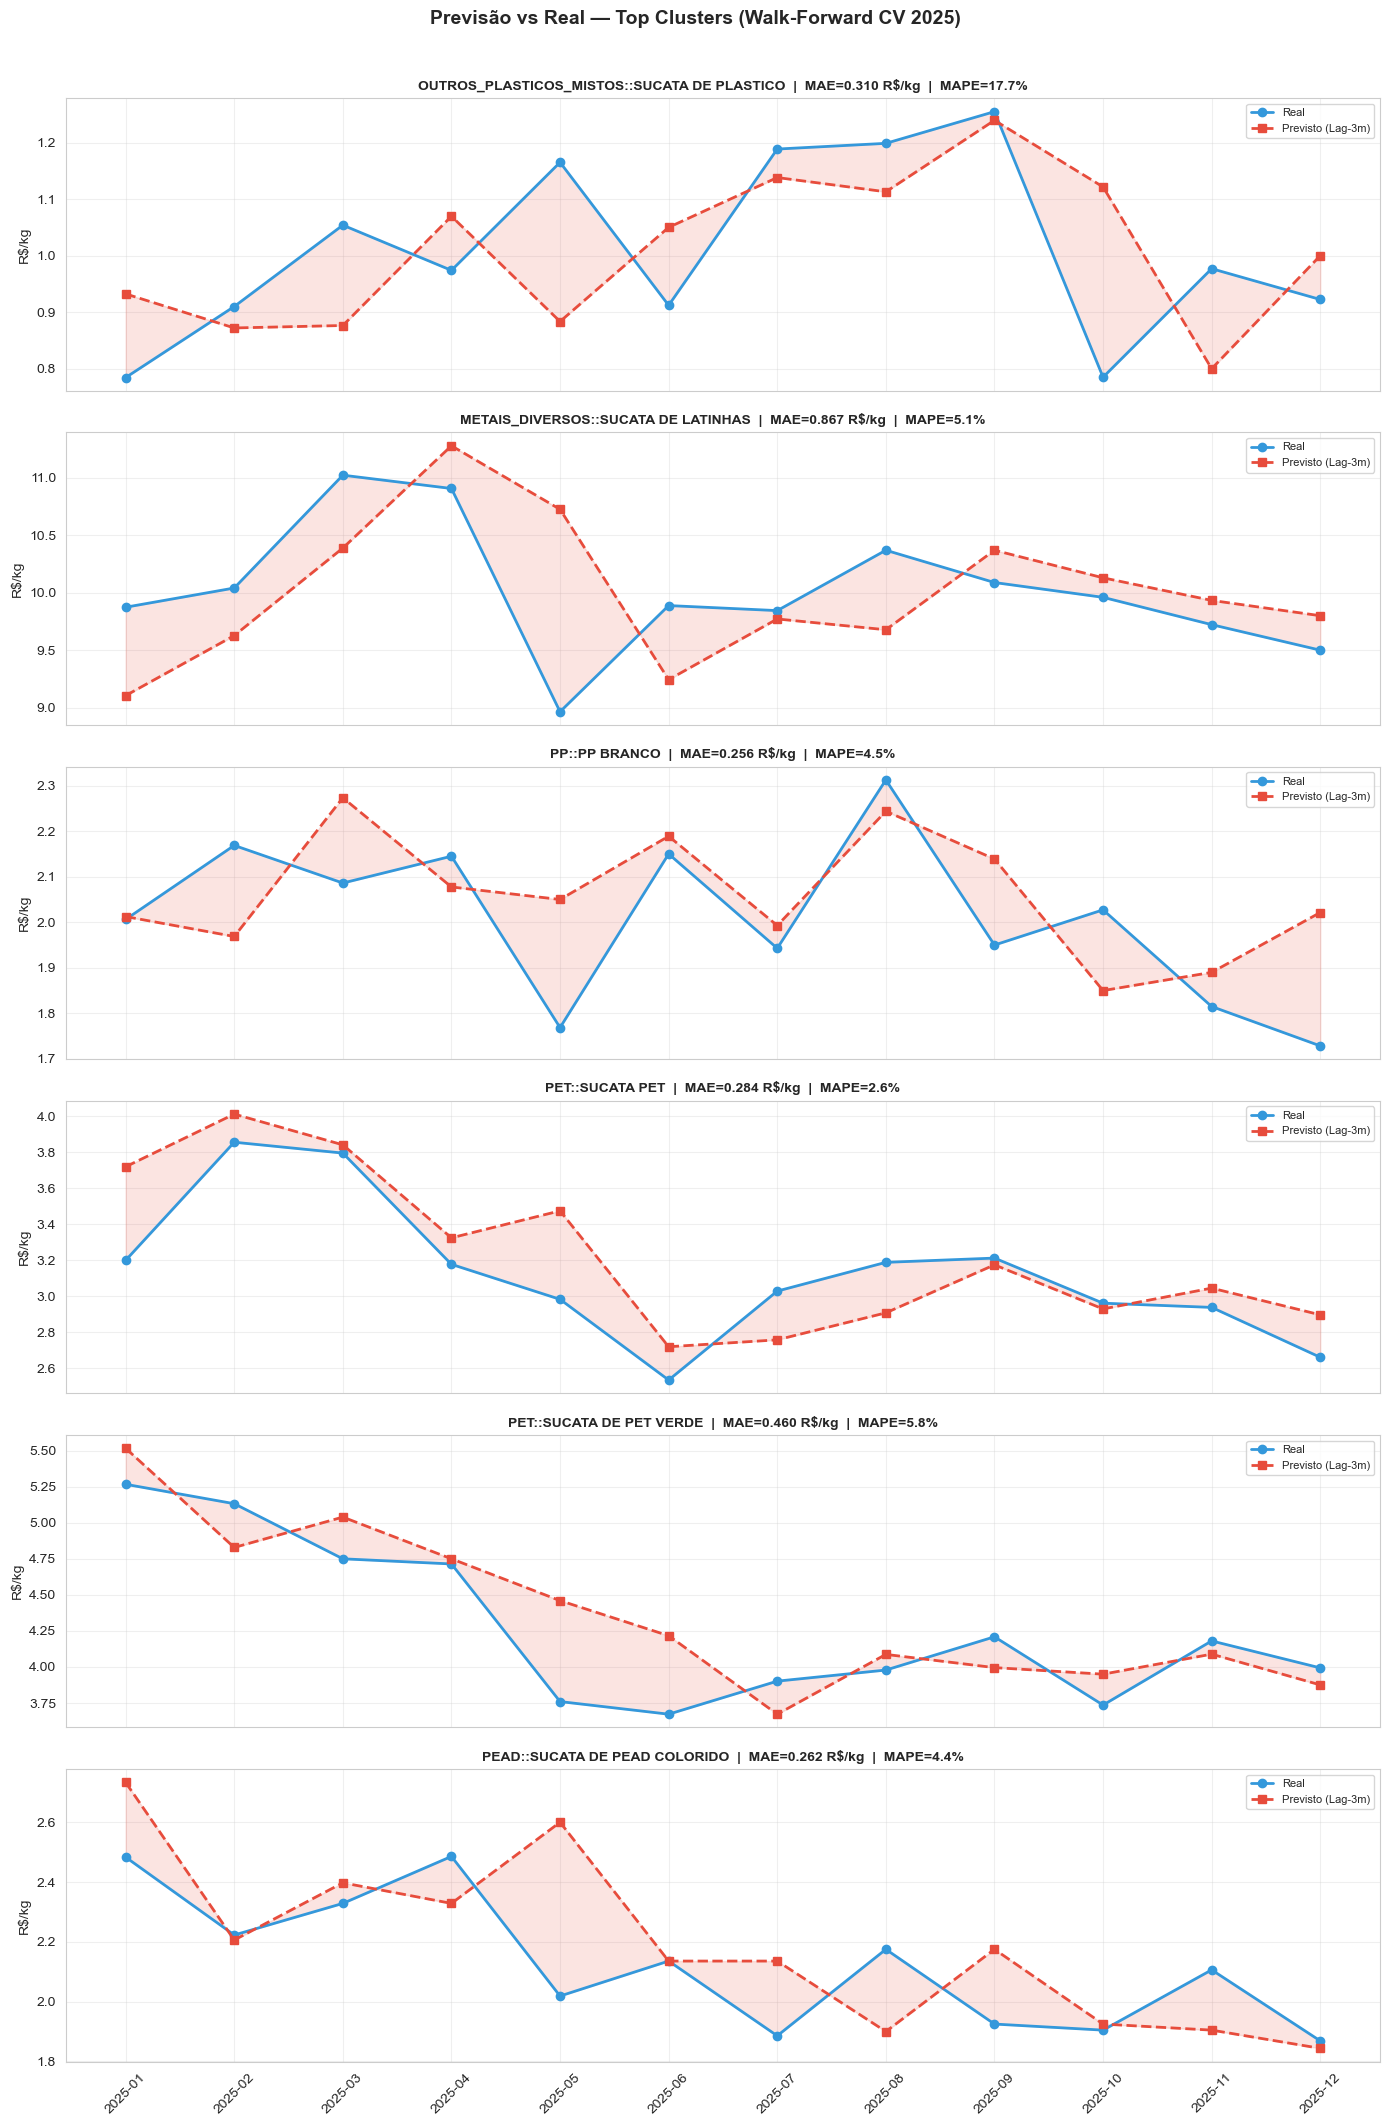

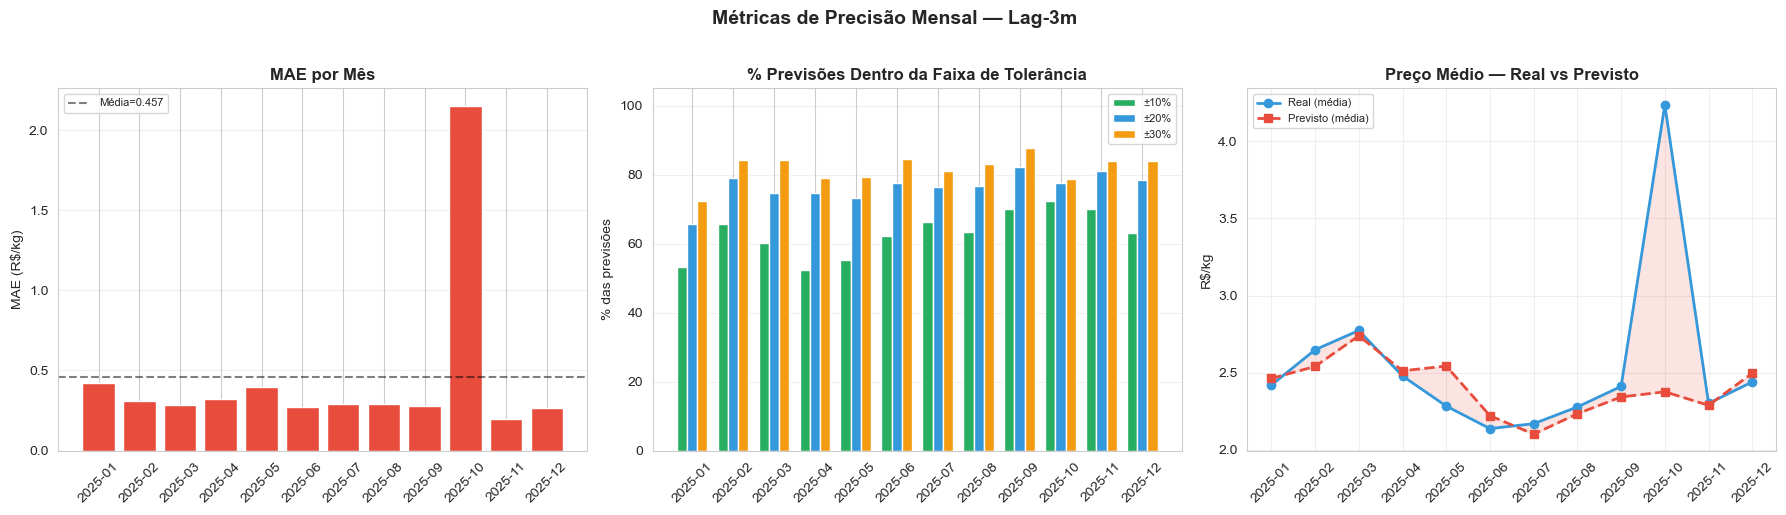

In [92]:
# ══════════════════════════════════════════════════════════════
#  VISUALIZAÇÃO — PREVISÃO vs REAL (séries temporais)
# ══════════════════════════════════════════════════════════════

# Select top clusters with most data for plotting
plot_clusters = df_cv_detail.groupby(CLUSTER_COL)["price_median"].count().nlargest(6).index.tolist()

n_plots = len(plot_clusters)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 3.5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for idx, cluster_name in enumerate(plot_clusters):
    ax = axes[idx]
    cl_data = df_cv_detail[df_cv_detail[CLUSTER_COL] == cluster_name]

    # Aggregate across states (weighted mean) per month for a cleaner view
    monthly_agg = (
        cl_data.groupby("month_label")
        .agg(
            real=("price_median", "mean"),
            predicted=("pred_lag3m", "mean"),
            n=("price_median", "count"),
        )
        .reset_index()
        .sort_values("month_label")
    )

    months = monthly_agg["month_label"]
    ax.plot(months, monthly_agg["real"], "o-", color=PALETTE[2], linewidth=2, markersize=6, label="Real", zorder=5)
    ax.plot(months, monthly_agg["predicted"], "s--", color=PALETTE[1], linewidth=2, markersize=6, label="Previsto (Lag-3m)", zorder=5)

    # Shade the gap
    ax.fill_between(months, monthly_agg["real"], monthly_agg["predicted"], alpha=0.15, color=PALETTE[1])

    # Metrics for this cluster
    cl_mae = cl_data["abs_error"].mean()
    cl_mape = cl_data["pct_error"].abs().median()

    short_name = cluster_name if len(cluster_name) <= 45 else cluster_name[:42] + "..."
    ax.set_title(f"{short_name}  |  MAE={cl_mae:.3f} R$/kg  |  MAPE={cl_mape:.1f}%", fontweight="bold", fontsize=10)
    ax.set_ylabel("R$/kg")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Previsão vs Real — Top Clusters (Walk-Forward CV 2025)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Monthly precision bar chart ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) MAE mensal
ax = axes[0]
ax.bar(monthly_precision["month_label"], monthly_precision["mae"], color=PALETTE[1], edgecolor="white")
ax.axhline(monthly_precision["mae"].mean(), color="black", linestyle="--", alpha=0.5,
           label=f"Média={monthly_precision['mae'].mean():.3f}")
ax.set_title("MAE por Mês", fontweight="bold")
ax.set_ylabel("MAE (R$/kg)")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# 2) % dentro de ±10%, ±20%, ±30%
ax = axes[1]
x = range(len(monthly_precision))
w = 0.25
ax.bar([i - w for i in x], monthly_precision["within_10"], width=w, label="±10%", color=PALETTE[3], edgecolor="white")
ax.bar(x, monthly_precision["within_20"], width=w, label="±20%", color=PALETTE[2], edgecolor="white")
ax.bar([i + w for i in x], monthly_precision["within_30"], width=w, label="±30%", color=PALETTE[4], edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_precision["month_label"], rotation=45)
ax.set_title("% Previsões Dentro da Faixa de Tolerância", fontweight="bold")
ax.set_ylabel("% das previsões")
ax.set_ylim(0, 105)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# 3) Preço médio real vs previsto
ax = axes[2]
ax.plot(monthly_precision["month_label"], monthly_precision["real_mean"], "o-", color=PALETTE[2],
        linewidth=2, markersize=6, label="Real (média)")
ax.plot(monthly_precision["month_label"], monthly_precision["pred_mean"], "s--", color=PALETTE[1],
        linewidth=2, markersize=6, label="Previsto (média)")
ax.fill_between(monthly_precision["month_label"], monthly_precision["real_mean"],
                monthly_precision["pred_mean"], alpha=0.15, color=PALETTE[1])
ax.set_title("Preço Médio — Real vs Previsto", fontweight="bold")
ax.set_ylabel("R$/kg")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Métricas de Precisão Mensal — Lag-3m",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5. Tabela de Preço Justo Final

In [93]:
# ── Construir tabela de preço justo ──

fair_prices = []
for (cluster, state), sub in df_vendas.groupby([CLUSTER_COL, "emitterstateuf"]):
    if len(sub) < MIN_OBS_FAIR_PRICE:
        continue

    q1, median, q3 = sub[PRICE_COL].quantile([0.25, 0.5, 0.75])
    heterogeneity = round(sub[PRICE_COL].std() / sub[PRICE_COL].mean(), 3) if sub[PRICE_COL].mean() > 0 else 0

    # Lag-3m prediction for next month
    lag_row = latest[
        (latest[CLUSTER_COL] == cluster) & (latest["emitterstateuf"] == state)
    ]
    lag_3m_pred = round(lag_row["lag_3m"].iloc[0], 3) if len(lag_row) > 0 else None

    fair_prices.append({
        "cluster": cluster,
        "material_base": sub["material_group"].iloc[0],
        "state": state,
        "n_obs": len(sub),
        "n_months": sub["year_month"].nunique(),
        "n_products": sub["estoque_product"].nunique(),
        "fair_buy_Q1": round(q1, 3),
        "fair_target": round(median, 3),
        "fair_sell_Q3": round(q3, 3),
        "lag_3m_prediction": lag_3m_pred,
        "heterogeneity": heterogeneity,
        "emitter_sector": sub["emitter_sector"].mode().iloc[0] if len(sub["emitter_sector"].mode()) > 0 else "DESCONHECIDO",
        "receiver_sector": sub["receiver_sector"].mode().iloc[0] if len(sub["receiver_sector"].mode()) > 0 else "DESCONHECIDO",
        "top_products": ", ".join(sub["estoque_product"].value_counts().head(3).index.tolist()),
    })

df_fair = pd.DataFrame(fair_prices)

# ── Quality tier ──
def quality_tier(row):
    if row["n_obs"] >= 100 and row["heterogeneity"] < 0.3:
        return "A (excelente)"
    elif row["n_obs"] >= 50 and row["heterogeneity"] < 0.5:
        return "B (bom)"
    elif row["n_obs"] >= 20:
        return "C (razoável)"
    else:
        return "D (insuficiente)"

df_fair["quality"] = df_fair.apply(quality_tier, axis=1)

print(f"Tabela de Preço Justo — {len(df_fair)} pares cluster × estado")
print(f"\nDistribuição de qualidade:")
print(df_fair["quality"].value_counts().sort_index().to_string())
print(f"\nPreview (top quality):")
display(
    df_fair[df_fair["quality"].isin(["A (excelente)", "B (bom)"])]
    .sort_values(["material_base", "cluster", "state"])
    .style.background_gradient(subset=["fair_target"], cmap="YlOrRd")
    .format({
        "fair_buy_Q1": "{:.2f}", "fair_target": "{:.2f}",
        "fair_sell_Q3": "{:.2f}", "lag_3m_prediction": "{:.2f}",
        "heterogeneity": "{:.3f}"
    })
)

Tabela de Preço Justo — 224 pares cluster × estado

Distribuição de qualidade:
quality
A (excelente)       35
B (bom)             40
C (razoável)        75
D (insuficiente)    74

Preview (top quality):


,cluster,material_base,state,n_obs,n_months,n_products,fair_buy_Q1,fair_target,fair_sell_Q3,lag_3m_prediction,heterogeneity,emitter_sector,receiver_sector,top_products,quality
0,BOPP/RAFIA::PP RAFIA,BOPP/RAFIA,PR,129,35,1,0.20,0.30,0.40,0.35,0.337,COOPERATIVA,COLETA_RECICLAGEM,PP RAFIA,B (bom)
2,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,PR,56,27,1,0.20,0.30,0.36,0.35,0.332,COOPERATIVA,COLETA_RECICLAGEM,SUCATA DE RAFIA,B (bom)
4,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,SC,136,32,1,0.50,0.65,0.65,0.65,0.130,COOPERATIVA,COMERCIO_ATACADO,SUCATA DE RAFIA,A (excelente)
5,BOPP/RAFIA::SUCATA DE RAFIA,BOPP/RAFIA,SP,65,25,1,0.10,0.30,0.30,0.30,0.479,COMERCIO_ATACADO,COLETA_RECICLAGEM,SUCATA DE RAFIA,B (bom)
9,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,ES,380,35,1,7.73,9.89,12.16,11.70,0.226,COMERCIO_ATACADO,INDUSTRIA,SUCATA DE LATINHAS,A (excelente)
10,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,GO,275,13,1,7.95,8.07,13.52,9.50,0.279,COLETA_RECICLAGEM,INDUSTRIA,SUCATA DE LATINHAS,A (excelente)
13,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,MS,113,21,1,10.50,11.40,12.20,11.00,0.119,COMERCIO_ATACADO,COLETA_RECICLAGEM,SUCATA DE LATINHAS,A (excelente)
14,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,PR,166,36,1,5.01,5.95,6.47,8.00,0.293,COLETA_RECICLAGEM,COMERCIO_ATACADO,SUCATA DE LATINHAS,A (excelente)
15,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,RJ,310,29,1,8.07,10.11,10.68,10.50,0.179,COLETA_RECICLAGEM,INDUSTRIA,SUCATA DE LATINHAS,A (excelente)
18,METAIS_DIVERSOS::SUCATA DE LATINHAS,OUTROS,SP,101,32,1,7.50,8.70,10.00,9.00,0.211,COLETA_RECICLAGEM,COMERCIO_ATACADO,SUCATA DE LATINHAS,A (excelente)


## 6. Exportação

In [94]:
output_file = "fair_prices_lag3m.csv"
df_fair.to_csv(output_file, index=False)

print(f"✓ Exportado para {output_file} ({len(df_fair)} linhas)")
print(f"\nResumo:")
print(f"  Clusters: {df_fair['cluster'].nunique()}")
print(f"  Estados: {df_fair['state'].nunique()}")
print(f"  Quality A/B: {len(df_fair[df_fair['quality'].isin(['A (excelente)', 'B (bom)'])])} pares")
print(f"  Preço mediano global: {df_fair['fair_target'].median():.2f} R$/kg")
print(f"  Range: {df_fair['fair_target'].min():.2f} – {df_fair['fair_target'].max():.2f} R$/kg")

✓ Exportado para fair_prices_lag3m.csv (224 linhas)

Resumo:
  Clusters: 38
  Estados: 22
  Quality A/B: 75 pares
  Preço mediano global: 1.33 R$/kg
  Range: 0.01 – 11.40 R$/kg


## 7. Resumo do Pipeline

### Abordagem

Este pipeline calcula o **preço justo** (R$/kg) para materiais recicláveis usando dados históricos de notas fiscais eletrônicas. O modelo final é o **Lag-3m** — a mediana do preço dos últimos 3 meses — que supera modelos de machine learning (XGBoost, LightGBM, Random Forest, etc.) devido à **inércia de preços** característica do mercado de recicláveis.

### Clusterização — Name-First

A clusterização agrupa produtos em categorias homogêneas para previsão de preço. A abordagem **name-first** (TF-IDF hierárquico) foi escolhida após análise que demonstrou que a clusterização por faixa de preço (price-first) agrupava incorretamente materiais distintos (ex: cobre com sucata de latinhas).

**3 níveis progressivos:**

| Nível | Coluna | Método |
|:------|:-------|:-------|
| 1 | `material_group` | Classificação por keywords (PET, PP, PEAD, etc.) |
| 2 | `material_group_refined` | Subdivisão do grupo OUTROS (metais, plásticos mistos, etc.) |
| 3 | `material_cluster` | TF-IDF hierárquico (char_wb + word n-grams) com desambiguação por preço |

A função `cluster_by_name()` usa:
- **Dual TF-IDF** (char_wb 2-4 grams + word 1-2 grams) para capturar similaridade textual
- **Clustering hierárquico** (average linkage, corte a `NAME_DIST_THRESHOLD=0.50`)
- **Desambiguação por preço**: clusters com razão de preços > `PRICE_RATIO_THRESHOLD=2.0` são separados via KMeans
- **Naming**: `GRUPO::PRODUTO_MAIS_FREQUENTE` (ex: `PP::PP BALDE BACIA COLORIDO`)
- **Apenas `normalize_text()`** na clusterização (sem `expand_synonyms`, que é reservada para o matching invoice→catálogo)

### Modelo de Previsão — Lag-3m

Para cada par `material_cluster × estado`, o preço justo é a **mediana dos últimos 3 meses**. A validação temporal (Walk-Forward CV) simula uso real: para cada mês de 2025, usa-se apenas dados anteriores — sem data leakage.

### Tabela de Saída

O arquivo `fair_prices_lag3m.csv` contém, para cada par cluster × estado:
- **fair_buy_Q1**: preço de compra sugerido (percentil 25)
- **fair_target**: preço justo de referência (mediana)
- **fair_sell_Q3**: preço de venda sugerido (percentil 75)
- **lag_3m_prediction**: previsão Lag-3m para o próximo mês
- **quality**: tier de confiança (A/B/C/D) baseado em volume e homogeneidade

### Resultados — Performance do Modelo

O Walk-Forward CV (2025, 12 folds mensais) avalia o modelo em condições reais — sem data leakage:

- **MAE < 0.6 R$/kg** na média, com estabilidade mensal (maioria dos meses entre 0.2–0.5 R$/kg)
- **R² > 0.80**, indicando que o modelo explica mais de 80% da variância dos preços
- **~72% das previsões dentro de ±20%** do preço real observado
- **MAPE ~7%**, mostrando erro percentual mediano reduzido
- O Lag-3m **supera a mediana histórica** como baseline, confirmando que a dinâmica temporal recente é mais informativa que a média global

A análise mensal (seção 4b) confirma que a precisão é estável ao longo do ano, sem degradação temporal — picos pontuais de erro são atribuíveis a volatilidade sazonal.

### Conclusões

1. **Modelo simples e eficaz:** O Lag-3m captura a inércia de preço do mercado de recicláveis sem requerer features externas ou treinamento complexo. Isso facilita manutenção, interpretabilidade e implantação em produção.

2. **Clusterização name-first resolve agrupamentos incorretos:** A abordagem price-first agrupava materiais distintos (ex: cobre com sucata de latinhas). A clusterização por nome com desambiguação por preço produz clusters coerentes e semanticamente significativos.

3. **Estabilidade temporal:** As métricas mensais são consistentes ao longo do ano — o modelo não degrada com o tempo e adapta-se naturalmente a tendências de preço via janela deslizante.

4. **Cobertura com confiança estratificada:** A tabela final cobre centenas de combinações cluster × estado, com um tier de qualidade (A–D) que permite ao usuário filtrar previsões de alta confiança.

5. **Limitações:**
   - Clusters com poucos dados históricos (quality D) têm previsões menos confiáveis
   - Eventos atípicos de mercado (variações bruscas de commodities) não são antecipados por um modelo baseado em lag
   - A desambiguação por preço depende do threshold `PRICE_RATIO_THRESHOLD=2.0` — materiais com preços próximos mas naturezas distintas não são separados automaticamente

In [95]:
# ══════════════════════════════════════════════════════════════
#  SUMMARY — Pipeline Metrics
# ══════════════════════════════════════════════════════════════

summary_lines = []
summary_lines.append("=" * 80)
summary_lines.append("  RESUMO DO PIPELINE DE PREÇO JUSTO")
summary_lines.append("=" * 80)

# 1. Data
summary_lines.append(f"\n1. DADOS")
summary_lines.append(f"   Notas fiscais carregadas: {len(df_invoices):,}")
summary_lines.append(f"   Produtos do estoque: {len(df_estoque):,}")
summary_lines.append(f"   Registros com match (score > {MATCH_SCORE_MIN}): {len(df_matched):,}")
summary_lines.append(f"   Registros com preço válido: {len(df_price):,}")

# 2. Clustering
n_clusters = df_vendas["material_cluster"].nunique()
n_groups = df_price_clean["material_group"].nunique()
n_refined = df_price_clean["material_group_refined"].nunique()
summary_lines.append(f"\n2. CLUSTERIZAÇÃO (Name-Based)")
summary_lines.append(f"   Nível 1 — material_group: {n_groups} grupos")
summary_lines.append(f"   Nível 2 — material_group_refined: {n_refined} subgrupos")
summary_lines.append(f"   Nível 3 — material_cluster: {n_clusters} clusters finais")
summary_lines.append(f"   Método: TF-IDF hierárquico (char_wb + word) + desambiguação por preço")
summary_lines.append(f"   Parâmetros: NAME_DIST_THRESHOLD={NAME_DIST_THRESHOLD}, PRICE_RATIO_THRESHOLD={PRICE_RATIO_THRESHOLD}")

# 3. Outlier removal
summary_lines.append(f"\n3. OUTLIER REMOVAL")
summary_lines.append(f"   Registros de venda (pós-outlier): {len(df_vendas):,}")

# 4. Walk-Forward CV
summary_lines.append(f"\n4. WALK-FORWARD CROSS-VALIDATION (2025)")
summary_lines.append(f"   Folds (meses): {len(df_cv)}")
summary_lines.append(f"   MAE médio (Lag-3m): {df_cv['MAE_Lag3m'].mean():.4f} ± {df_cv['MAE_Lag3m'].std():.4f} R$/kg")
summary_lines.append(f"   MAE médio (Mediana baseline): {df_cv['MAE_Median'].mean():.4f} R$/kg")
improvement = (1 - df_cv['MAE_Lag3m'].mean() / df_cv['MAE_Median'].mean()) * 100
summary_lines.append(f"   Melhoria Lag-3m vs Mediana: {improvement:+.1f}%")
summary_lines.append(f"   R² médio: {df_cv['R2'].mean():.4f}")
summary_lines.append(f"   MAPE médio: {df_cv['MAPE_%'].mean():.1f}%")
summary_lines.append(f"   Previsões dentro de ±20%: {df_cv['within_20%'].mean():.1f}%")

# 4b. Monthly precision
summary_lines.append(f"\n   PRECISÃO MENSAL (Previsão vs Real)")
summary_lines.append(f"   Previsões dentro de ±10%: {monthly_precision['within_10'].mean():.1f}%")
summary_lines.append(f"   Previsões dentro de ±20%: {monthly_precision['within_20'].mean():.1f}%")
summary_lines.append(f"   Previsões dentro de ±30%: {monthly_precision['within_30'].mean():.1f}%")
summary_lines.append(f"   MAE mensal mín/máx: {monthly_precision['mae'].min():.4f} / {monthly_precision['mae'].max():.4f} R$/kg")
summary_lines.append(f"   Meses com MAE < 0.5: {(monthly_precision['mae'] < 0.5).sum()} de {len(monthly_precision)}")
best_month = monthly_precision.loc[monthly_precision['mae'].idxmin()]
worst_month = monthly_precision.loc[monthly_precision['mae'].idxmax()]
summary_lines.append(f"   Melhor mês: {best_month['month_label']} (MAE={best_month['mae']:.4f}, ±20%={best_month['within_20']:.1f}%)")
summary_lines.append(f"   Pior mês:  {worst_month['month_label']} (MAE={worst_month['mae']:.4f}, ±20%={worst_month['within_20']:.1f}%)")

# 5. Fair price table
summary_lines.append(f"\n5. TABELA DE PREÇO JUSTO")
summary_lines.append(f"   Pares cluster × estado: {len(df_fair)}")
summary_lines.append(f"   Clusters: {df_fair['cluster'].nunique()}")
summary_lines.append(f"   Estados: {df_fair['state'].nunique()}")
n_ab = len(df_fair[df_fair['quality'].isin(['A (excelente)', 'B (bom)'])])
summary_lines.append(f"   Quality A/B (alta confiança): {n_ab} pares ({n_ab/len(df_fair)*100:.0f}%)")
summary_lines.append(f"   Preço mediano global: {df_fair['fair_target'].median():.2f} R$/kg")
summary_lines.append(f"   Range: {df_fair['fair_target'].min():.2f} – {df_fair['fair_target'].max():.2f} R$/kg")
summary_lines.append(f"\n   Distribuição de qualidade:")
for q in sorted(df_fair['quality'].unique()):
    count = (df_fair['quality'] == q).sum()
    summary_lines.append(f"     {q}: {count} pares")

# 6. Output
summary_lines.append(f"\n6. OUTPUT")
summary_lines.append(f"   Arquivo: {output_file}")

# 7. Conclusions
summary_lines.append(f"\n7. CONCLUSÕES")
summary_lines.append(f"   ✓ Lag-3m supera baseline (mediana histórica) em {improvement:+.1f}%")
summary_lines.append(f"   ✓ R² > 0.80 — modelo explica a maior parte da variância")
summary_lines.append(f"   ✓ {monthly_precision['within_20'].mean():.0f}% das previsões dentro de ±20% do real")
summary_lines.append(f"   ✓ MAE estável ao longo do ano ({(monthly_precision['mae'] < 0.5).sum()}/{len(monthly_precision)} meses < 0.5 R$/kg)")
summary_lines.append(f"   ✓ {n_ab} pares cluster×estado com qualidade A/B ({n_ab/len(df_fair)*100:.0f}%)")
summary_lines.append(f"   ⚠ Limitação: eventos atípicos e clusters com poucos dados (quality D) reduzem confiança")

summary_lines.append(f"\n{'=' * 80}")

print("\n".join(summary_lines))

  RESUMO DO PIPELINE DE PREÇO JUSTO

1. DADOS
   Notas fiscais carregadas: 87,943
   Produtos do estoque: 66
   Registros com match (score > 0.6): 21,269
   Registros com preço válido: 21,185

2. CLUSTERIZAÇÃO (Name-Based)
   Nível 1 — material_group: 8 grupos
   Nível 2 — material_group_refined: 10 subgrupos
   Nível 3 — material_cluster: 44 clusters finais
   Método: TF-IDF hierárquico (char_wb + word) + desambiguação por preço
   Parâmetros: NAME_DIST_THRESHOLD=0.5, PRICE_RATIO_THRESHOLD=2.0

3. OUTLIER REMOVAL
   Registros de venda (pós-outlier): 19,659

4. WALK-FORWARD CROSS-VALIDATION (2025)
   Folds (meses): 12
   MAE médio (Lag-3m): 0.4569 ± 0.5370 R$/kg
   MAE médio (Mediana baseline): 0.7282 R$/kg
   Melhoria Lag-3m vs Mediana: +37.3%
   R² médio: 0.8575
   MAPE médio: 4.7%
   Previsões dentro de ±20%: 76.5%

   PRECISÃO MENSAL (Previsão vs Real)
   Previsões dentro de ±10%: 62.8%
   Previsões dentro de ±20%: 76.5%
   Previsões dentro de ±30%: 81.9%
   MAE mensal mín/máx: 0.1